# Paddy Yield Forecasting - Data Pre-processing & Model Implementation




## Preprocessing Yield Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# Load the dataset
file_path = '/content/drive/MyDrive/Datasets/RAW_yield_data.csv'

maha_yield = pd.read_csv(file_path)

In [11]:
# Add a 'Cultivation_Season' column that matches the format of the weather data
maha_yield['Cultivation_Season'] = (maha_yield['Year'] - 1).astype(str) + '-' + maha_yield['Year'].astype(str)

maha_yield.to_csv('maha_yield.csv', index=False)

# Display the first few rows to verify
display(maha_yield.head())


,Year,District,Maha_Yield,Cultivation_Season
0,1979,POLONNARUWA,3547,1978-1979
1,1980,POLONNARUWA,3748,1979-1980
2,1981,POLONNARUWA,3737,1980-1981
3,1982,POLONNARUWA,4707,1981-1982
4,1983,POLONNARUWA,5274,1982-1983


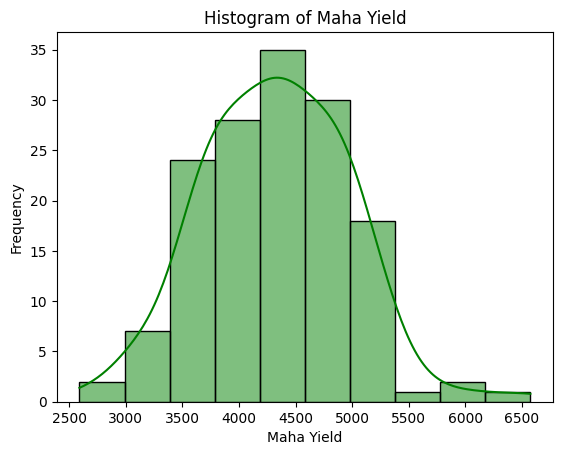

In [12]:
# Histogram of Maha yield
sns.histplot(maha_yield['Maha_Yield'], kde=True, bins=10, color='green')
plt.title('Histogram of Maha Yield')
plt.xlabel('Maha Yield')
plt.ylabel('Frequency')
plt.show()



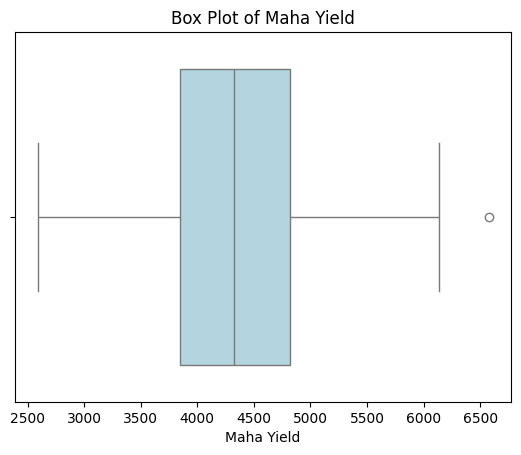

In [13]:
# Box Plot of Maha Yield
sns.boxplot(x=maha_yield['Maha_Yield'], color='lightblue')
plt.title('Box Plot of Maha Yield')
plt.xlabel('Maha Yield')
plt.show()

## Preprocessing Weather Dataset

In [14]:
file_path = '/content/drive/MyDrive/Datasets/RAW_monthly_weather_data.csv'

# Load the dataset
weather_data = pd.read_csv(file_path)
weather_data.head()


,Year,Month,District,Tmax,Tmin,Wind,SRAD,RH,Rain,Soil
0,1984,1,POLONNARUWA,28.44,22.09,2.69,12.71,89.72,365.56,0.91
1,1984,2,POLONNARUWA,29.21,22.74,2.91,11.65,89.85,326.22,0.97
2,1984,3,POLONNARUWA,31.06,21.32,1.74,19.75,81.56,135.18,0.87
3,1984,4,POLONNARUWA,32.06,22.93,2.21,18.61,84.53,250.59,0.79
4,1984,5,POLONNARUWA,32.02,23.28,2.88,21.00,83.32,39.05,0.73


### Handling Missing Values

In [15]:
# Select only numeric columns
numeric_columns = weather_data.select_dtypes(include=['number'])

# Check for missing values in numeric columns
missing_values_numeric = numeric_columns.isnull().sum()
print("Missing Values:\n", missing_values_numeric, "\n")

# Check for negative values in numeric columns
negative_values_numeric = (numeric_columns < 0).sum()
print("Negative Values:\n", negative_values_numeric)


Missing Values:
 Year     0
Month    0
Tmax     0
Tmin     0
Wind     0
SRAD     0
RH       0
Rain     0
Soil     0
dtype: int64 

Negative Values:
 Year     0
Month    0
Tmax     0
Tmin     0
Wind     0
SRAD     0
RH       0
Rain     0
Soil     0
dtype: int64


### Determine Relevant Months for Maha Season

The Maha season in Sri Lanka spans from **September to March** in the following year, roughly covering **Standard Meteorological Weeks (SMWs) 36 to 13**, which crosses over two calendar years. This aligns with the North-East Monsoon and represents one of the two main paddy cultivation seasons in Sri Lanka, as defined by the *Department of Census and Statistics in Sri Lanka*.

### Filter Data for the Maha Season

In [16]:
# Define Maha season months
maha_months_full = [9, 10, 11, 12, 1, 2, 3]

maha_season_data = weather_data[
    (
        ((weather_data['Month'].isin([9, 10, 11, 12])) & (weather_data['Year'] == 1984)) |  # Sep-Dec for 1984
        ((weather_data['Month'].isin([1, 2, 3])) & (weather_data['Year'] == 2015)) |        # Jan-Mar for 2015
        ((weather_data['Month'].isin(maha_months_full)) & (weather_data['Year'] > 1984) & (weather_data['Year'] < 2015))  # Full Maha season for 1985-2014
    )
]

# Display the filtered dataset
display(maha_season_data)


,Year,Month,District,Tmax,Tmin,Wind,SRAD,RH,Rain,Soil
8,1984,9,POLONNARUWA,35.05,21.91,3.54,19.81,76.73,301.86,0.54
9,1984,10,POLONNARUWA,30.90,20.35,3.24,18.66,83.97,113.58,0.65
10,1984,11,POLONNARUWA,30.11,21.86,2.10,16.61,86.68,303.79,0.70
11,1984,12,POLONNARUWA,29.84,19.93,2.67,15.23,85.72,95.29,0.75
12,1985,1,POLONNARUWA,28.92,21.73,2.61,16.55,86.11,117.61,0.72
...,...,...,...,...,...,...,...,...,...,...
1522,2014,11,HAMBANTOTA,29.84,25.01,3.97,15.19,84.22,375.87,0.88
1523,2014,12,HAMBANTOTA,28.72,24.89,3.36,13.51,86.73,707.49,0.95
1524,2015,1,HAMBANTOTA,28.63,23.60,4.17,19.91,82.36,40.71,0.89
1525,2015,2,HAMBANTOTA,28.78,24.00,4.19,19.79,82.72,165.27,0.84


### Handle Outliers in Monthly Weather Data

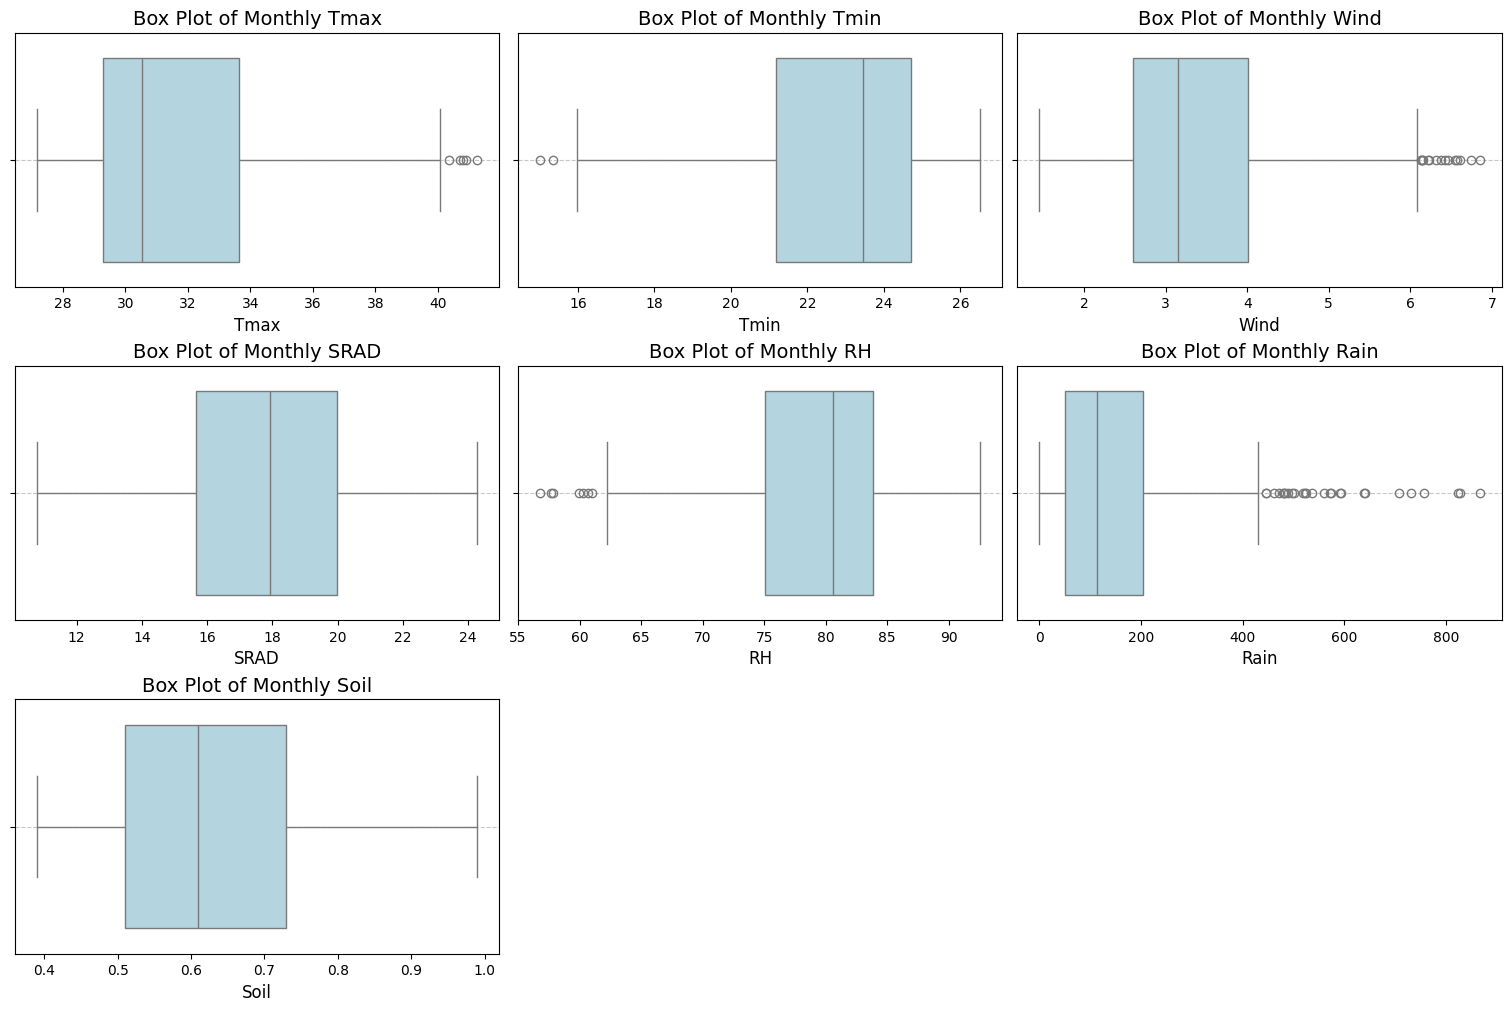

In [17]:
# Define features
features = ['Tmax', 'Tmin', 'Wind', 'SRAD', 'RH', 'Rain', 'Soil']

# Determine subplot layout
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10), constrained_layout=True)
axes = axes.flatten()

# Draw a boxplot for each feature
for i, feature in enumerate(features):
    sns.boxplot(ax=axes[i], x=maha_season_data[feature], color='lightblue')
    axes[i].set_title(f'Box Plot of Monthly {feature}', fontsize=14)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

# Show the plots
plt.show()



In [18]:
# Function for handling outliers
def cap_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return np.clip(df[column], lower_bound, upper_bound)


In [19]:
maha_season_data = maha_season_data.copy()

# Cap outliers for each feature
for feature in features:
    maha_season_data[feature] = cap_outliers(maha_season_data, feature)


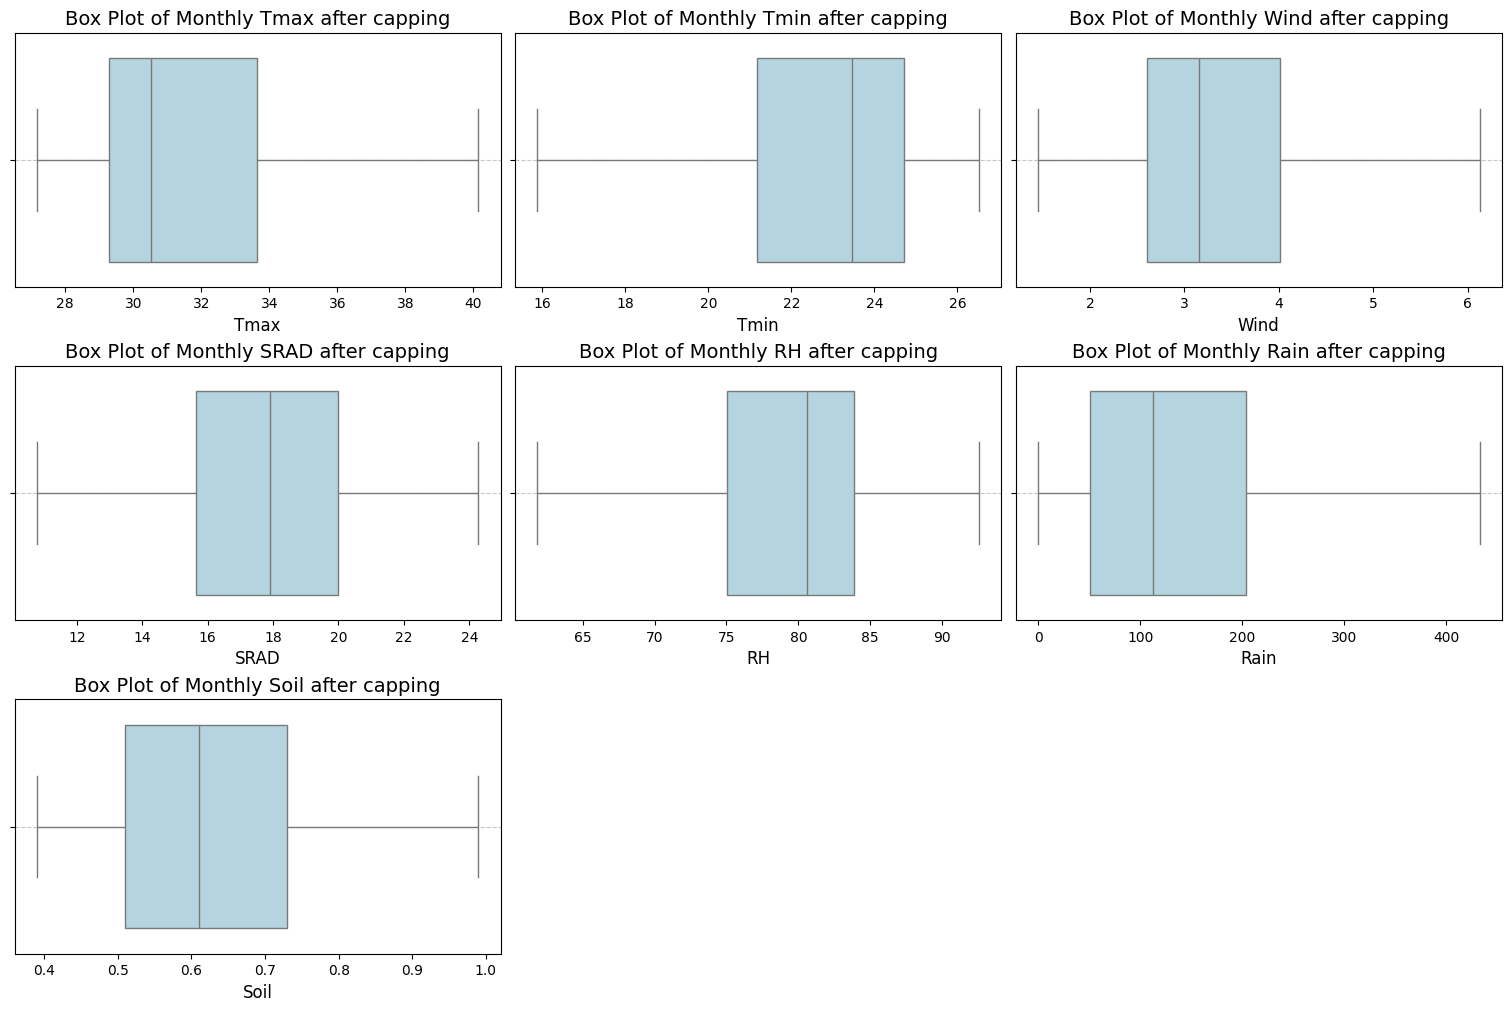

In [20]:
# Determine subplot layout
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10), constrained_layout=True)
axes = axes.flatten()

# Draw a boxplot for each feature
for i, feature in enumerate(features):
    sns.boxplot(ax=axes[i], x=maha_season_data[feature], color='lightblue')
    axes[i].set_title(f'Box Plot of Monthly {feature} after capping', fontsize=14)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

# Show the plots
plt.show()

### Calculate Simple Weather Indices

Simple weather indices are calculated to quantify the impact of different weather parameters over the entire cultivation season. These indices include:


* **Single Variable Indices**: Representing individual weather factors such as maximum temperature (Tmax), minimum temperature (Tmin), wind speed (Wind), solar radiation (SRAD), relative humidity (RH), and rainfall (Rain).
* **Interaction Indices**: Representing the interaction between two different weather variables, such as Tmax and Tmin. Interaction indices help capture the combined effect of two variables over the season.
The goal is to calculate a single value for each index that represents the overall impact during the cultivation season (e.g., Maha season).

In [33]:
# Assign Cultivation Season based on months
maha_season_data['Cultivation_Season'] = np.where(
    maha_season_data['Month'] >= 9,
    maha_season_data['Year'].astype(str) + '-' + (maha_season_data['Year'] + 1).astype(str),
    (maha_season_data['Year'] - 1).astype(str) + '-' + maha_season_data['Year'].astype(str)
)

cols = list(maha_season_data.columns)
cols.insert(1, cols.pop(cols.index('Cultivation_Season')))

# Apply new column order
maha_season_data = maha_season_data[cols]

# Display modified dataframe
display(maha_season_data.head(20))


,Year,Cultivation_Season,Month,District,Tmax,Tmin,Wind,SRAD,RH,Rain,...,Wind_SRAD,Wind_RH,Wind_Rain,Wind_Soil,SRAD_RH,SRAD_Rain,SRAD_Soil,RH_Rain,RH_Soil,Rain_Soil
8,1984,1984-1985,9,POLONNARUWA,35.05,21.91,3.54,19.81,76.73,301.86,...,70.1274,271.6242,1068.5844,1.9116,1520.0213,5979.8466,10.6974,23161.7178,41.4342,163.0044
9,1984,1984-1985,10,POLONNARUWA,30.90,20.35,3.24,18.66,83.97,113.58,...,60.4584,272.0628,367.9992,2.1060,1566.8802,2119.4028,12.1290,9537.3126,54.5805,73.8270
10,1984,1984-1985,11,POLONNARUWA,30.11,21.86,2.10,16.61,86.68,303.79,...,34.8810,182.0280,637.9590,1.4700,1439.7548,5045.9519,11.6270,26332.5172,60.6760,212.6530
11,1984,1984-1985,12,POLONNARUWA,29.84,19.93,2.67,15.23,85.72,95.29,...,40.6641,228.8724,254.4243,2.0025,1305.5156,1451.2667,11.4225,8168.2588,64.2900,71.4675
12,1985,1984-1985,1,POLONNARUWA,28.92,21.73,2.61,16.55,86.11,117.61,...,43.1955,224.7471,306.9621,1.8792,1425.1205,1946.4455,11.9160,10127.3971,61.9992,84.6792
13,1985,1984-1985,2,POLONNARUWA,30.31,20.39,2.21,17.13,83.26,98.51,...,37.8573,184.0046,217.7071,1.4365,1426.2438,1687.4763,11.1345,8201.9426,54.1190,64.0315
14,1985,1984-1985,3,POLONNARUWA,34.32,21.15,1.85,21.56,79.24,89.09,...,39.8860,146.5940,164.8165,1.0175,1708.4144,1920.7804,11.8580,7059.4916,43.5820,48.9995
20,1985,1985-1986,9,POLONNARUWA,35.93,23.15,3.94,19.80,71.95,105.31,...,78.0120,283.4830,414.9214,1.7730,1424.6100,2085.1380,8.9100,7577.0545,32.3775,47.3895
21,1985,1985-1986,10,POLONNARUWA,33.12,22.34,2.99,18.62,79.02,145.34,...,55.6738,236.2698,434.5666,1.5847,1471.3524,2706.2308,9.8686,11484.7668,41.8806,77.0302
22,1985,1985-1986,11,POLONNARUWA,30.06,19.96,2.47,16.16,84.38,221.24,...,39.9152,208.4186,546.4628,1.5808,1363.5808,3575.2384,10.3424,18668.2312,54.0032,141.5936


#### Calculate Interaction Weather Indices

In [22]:
interaction_terms = [
    ('Tmax', 'Tmin'), ('Tmax', 'Wind'), ('Tmax', 'SRAD'), ('Tmax', 'RH'), ('Tmax', 'Rain'), ('Tmax', 'Soil'),
    ('Tmin', 'Wind'), ('Tmin', 'SRAD'), ('Tmin', 'RH'), ('Tmin', 'Rain'), ('Tmin', 'Soil'),
    ('Wind', 'SRAD'), ('Wind', 'RH'), ('Wind', 'Rain'), ('Wind', 'Soil'),
    ('SRAD', 'RH'), ('SRAD', 'Rain'), ('SRAD', 'Soil'),
    ('RH', 'Rain'), ('RH', 'Soil'),
    ('Rain', 'Soil')
]

# Generate interaction terms
for var1, var2 in interaction_terms:
    maha_season_data[f'{var1}_{var2}'] = maha_season_data[var1] * maha_season_data[var2]

# Display the modified dataframe
display(maha_season_data.head())



,Year,Cultivation_Season,Month,District,Tmax,Tmin,Wind,SRAD,RH,Rain,...,Wind_SRAD,Wind_RH,Wind_Rain,Wind_Soil,SRAD_RH,SRAD_Rain,SRAD_Soil,RH_Rain,RH_Soil,Rain_Soil
8,1984,1984-1985,9,POLONNARUWA,35.05,21.91,3.54,19.81,76.73,301.86,...,70.1274,271.6242,1068.5844,1.9116,1520.0213,5979.8466,10.6974,23161.7178,41.4342,163.0044
9,1984,1984-1985,10,POLONNARUWA,30.90,20.35,3.24,18.66,83.97,113.58,...,60.4584,272.0628,367.9992,2.1060,1566.8802,2119.4028,12.1290,9537.3126,54.5805,73.8270
10,1984,1984-1985,11,POLONNARUWA,30.11,21.86,2.10,16.61,86.68,303.79,...,34.8810,182.0280,637.9590,1.4700,1439.7548,5045.9519,11.6270,26332.5172,60.6760,212.6530
11,1984,1984-1985,12,POLONNARUWA,29.84,19.93,2.67,15.23,85.72,95.29,...,40.6641,228.8724,254.4243,2.0025,1305.5156,1451.2667,11.4225,8168.2588,64.2900,71.4675
12,1985,1984-1985,1,POLONNARUWA,28.92,21.73,2.61,16.55,86.11,117.61,...,43.1955,224.7471,306.9621,1.8792,1425.1205,1946.4455,11.9160,10127.3971,61.9992,84.6792


#### Handle Outliers in Interaction Weather Indices

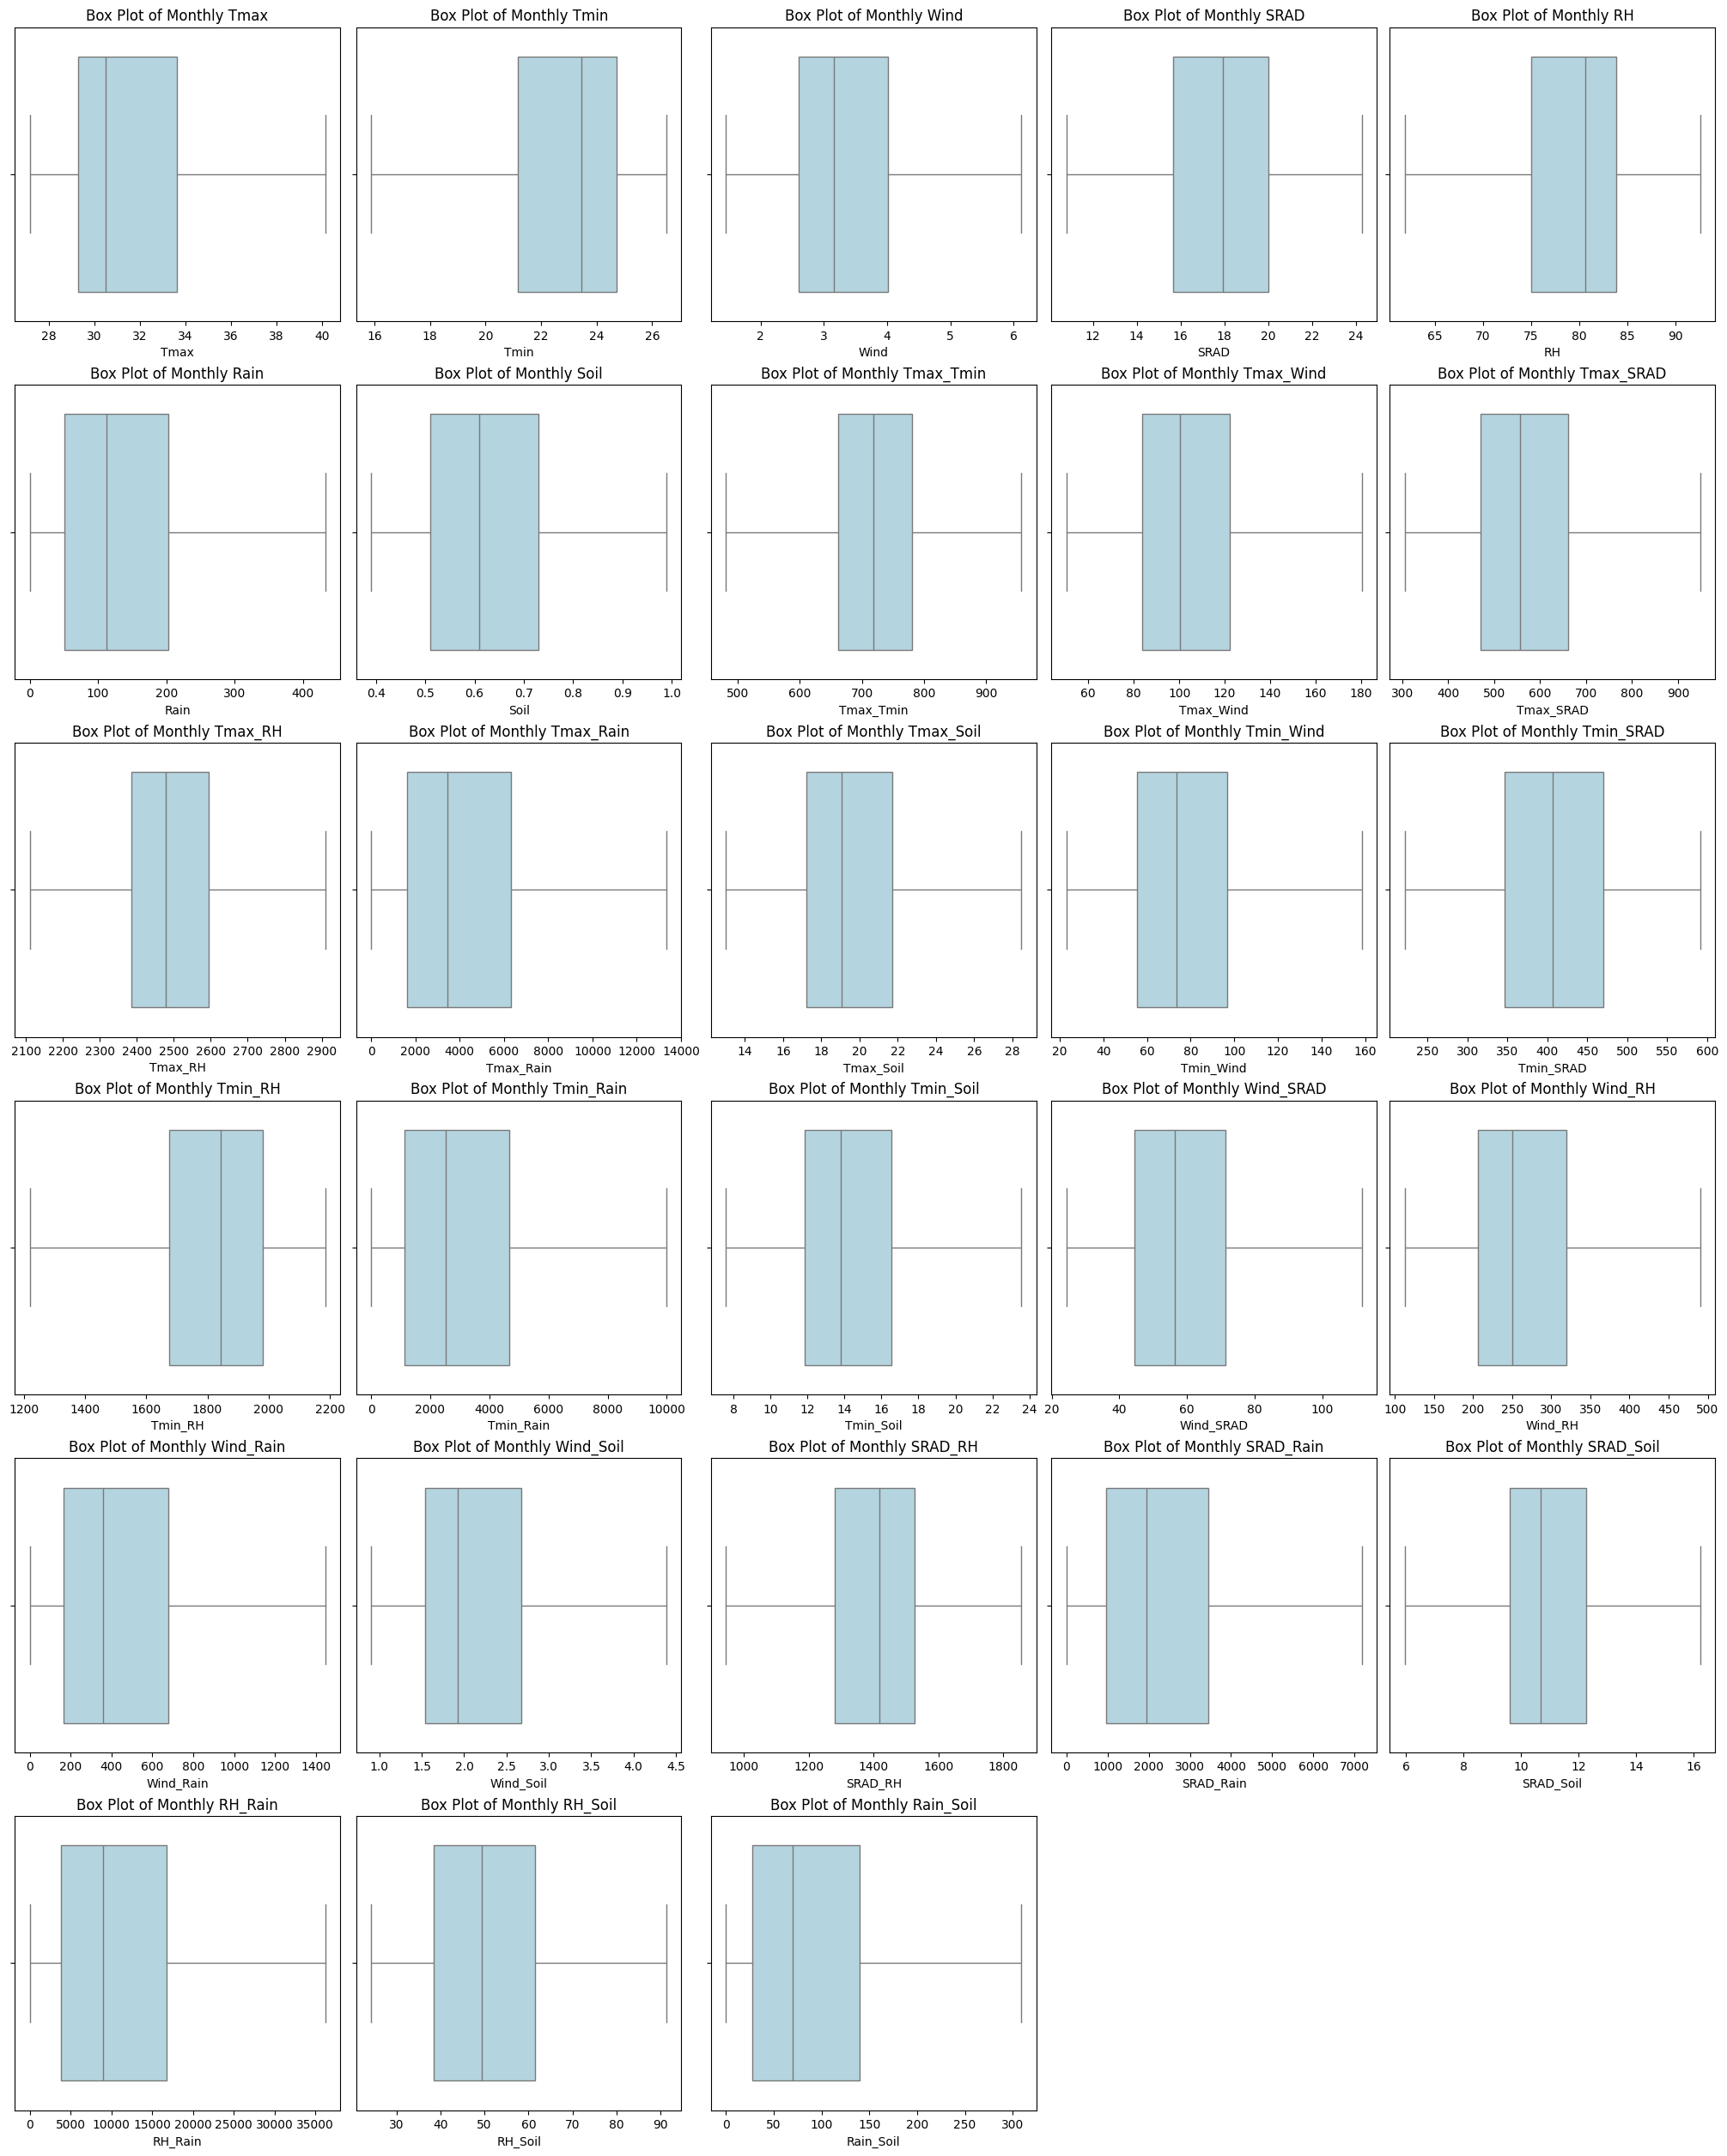

In [28]:
# Exclude 'Year' and 'Month' from numeric columns
numeric_cols_filtered = [col for col in maha_season_data.select_dtypes(include=['number']).columns if col not in ['Year', 'Month']]

# Set fixed rows and columns
num_rows = 6
num_cols = 5

# Create subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(20, 25), constrained_layout=True)
axes = axes.flatten()

num_plots = min(len(numeric_cols_filtered), len(axes))

# Plot each numeric column
for i in range(num_plots):
    col = numeric_cols_filtered[i]
    sns.boxplot(ax=axes[i], x=maha_season_data[col], color='lightblue')
    axes[i].set_title(f'Box Plot of Monthly {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)

for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

# Show the plots
plt.show()


In [25]:
# Cap outliers for each feature
for feature in numeric_cols_filtered:
    maha_season_data[feature] = cap_outliers(maha_season_data, feature)


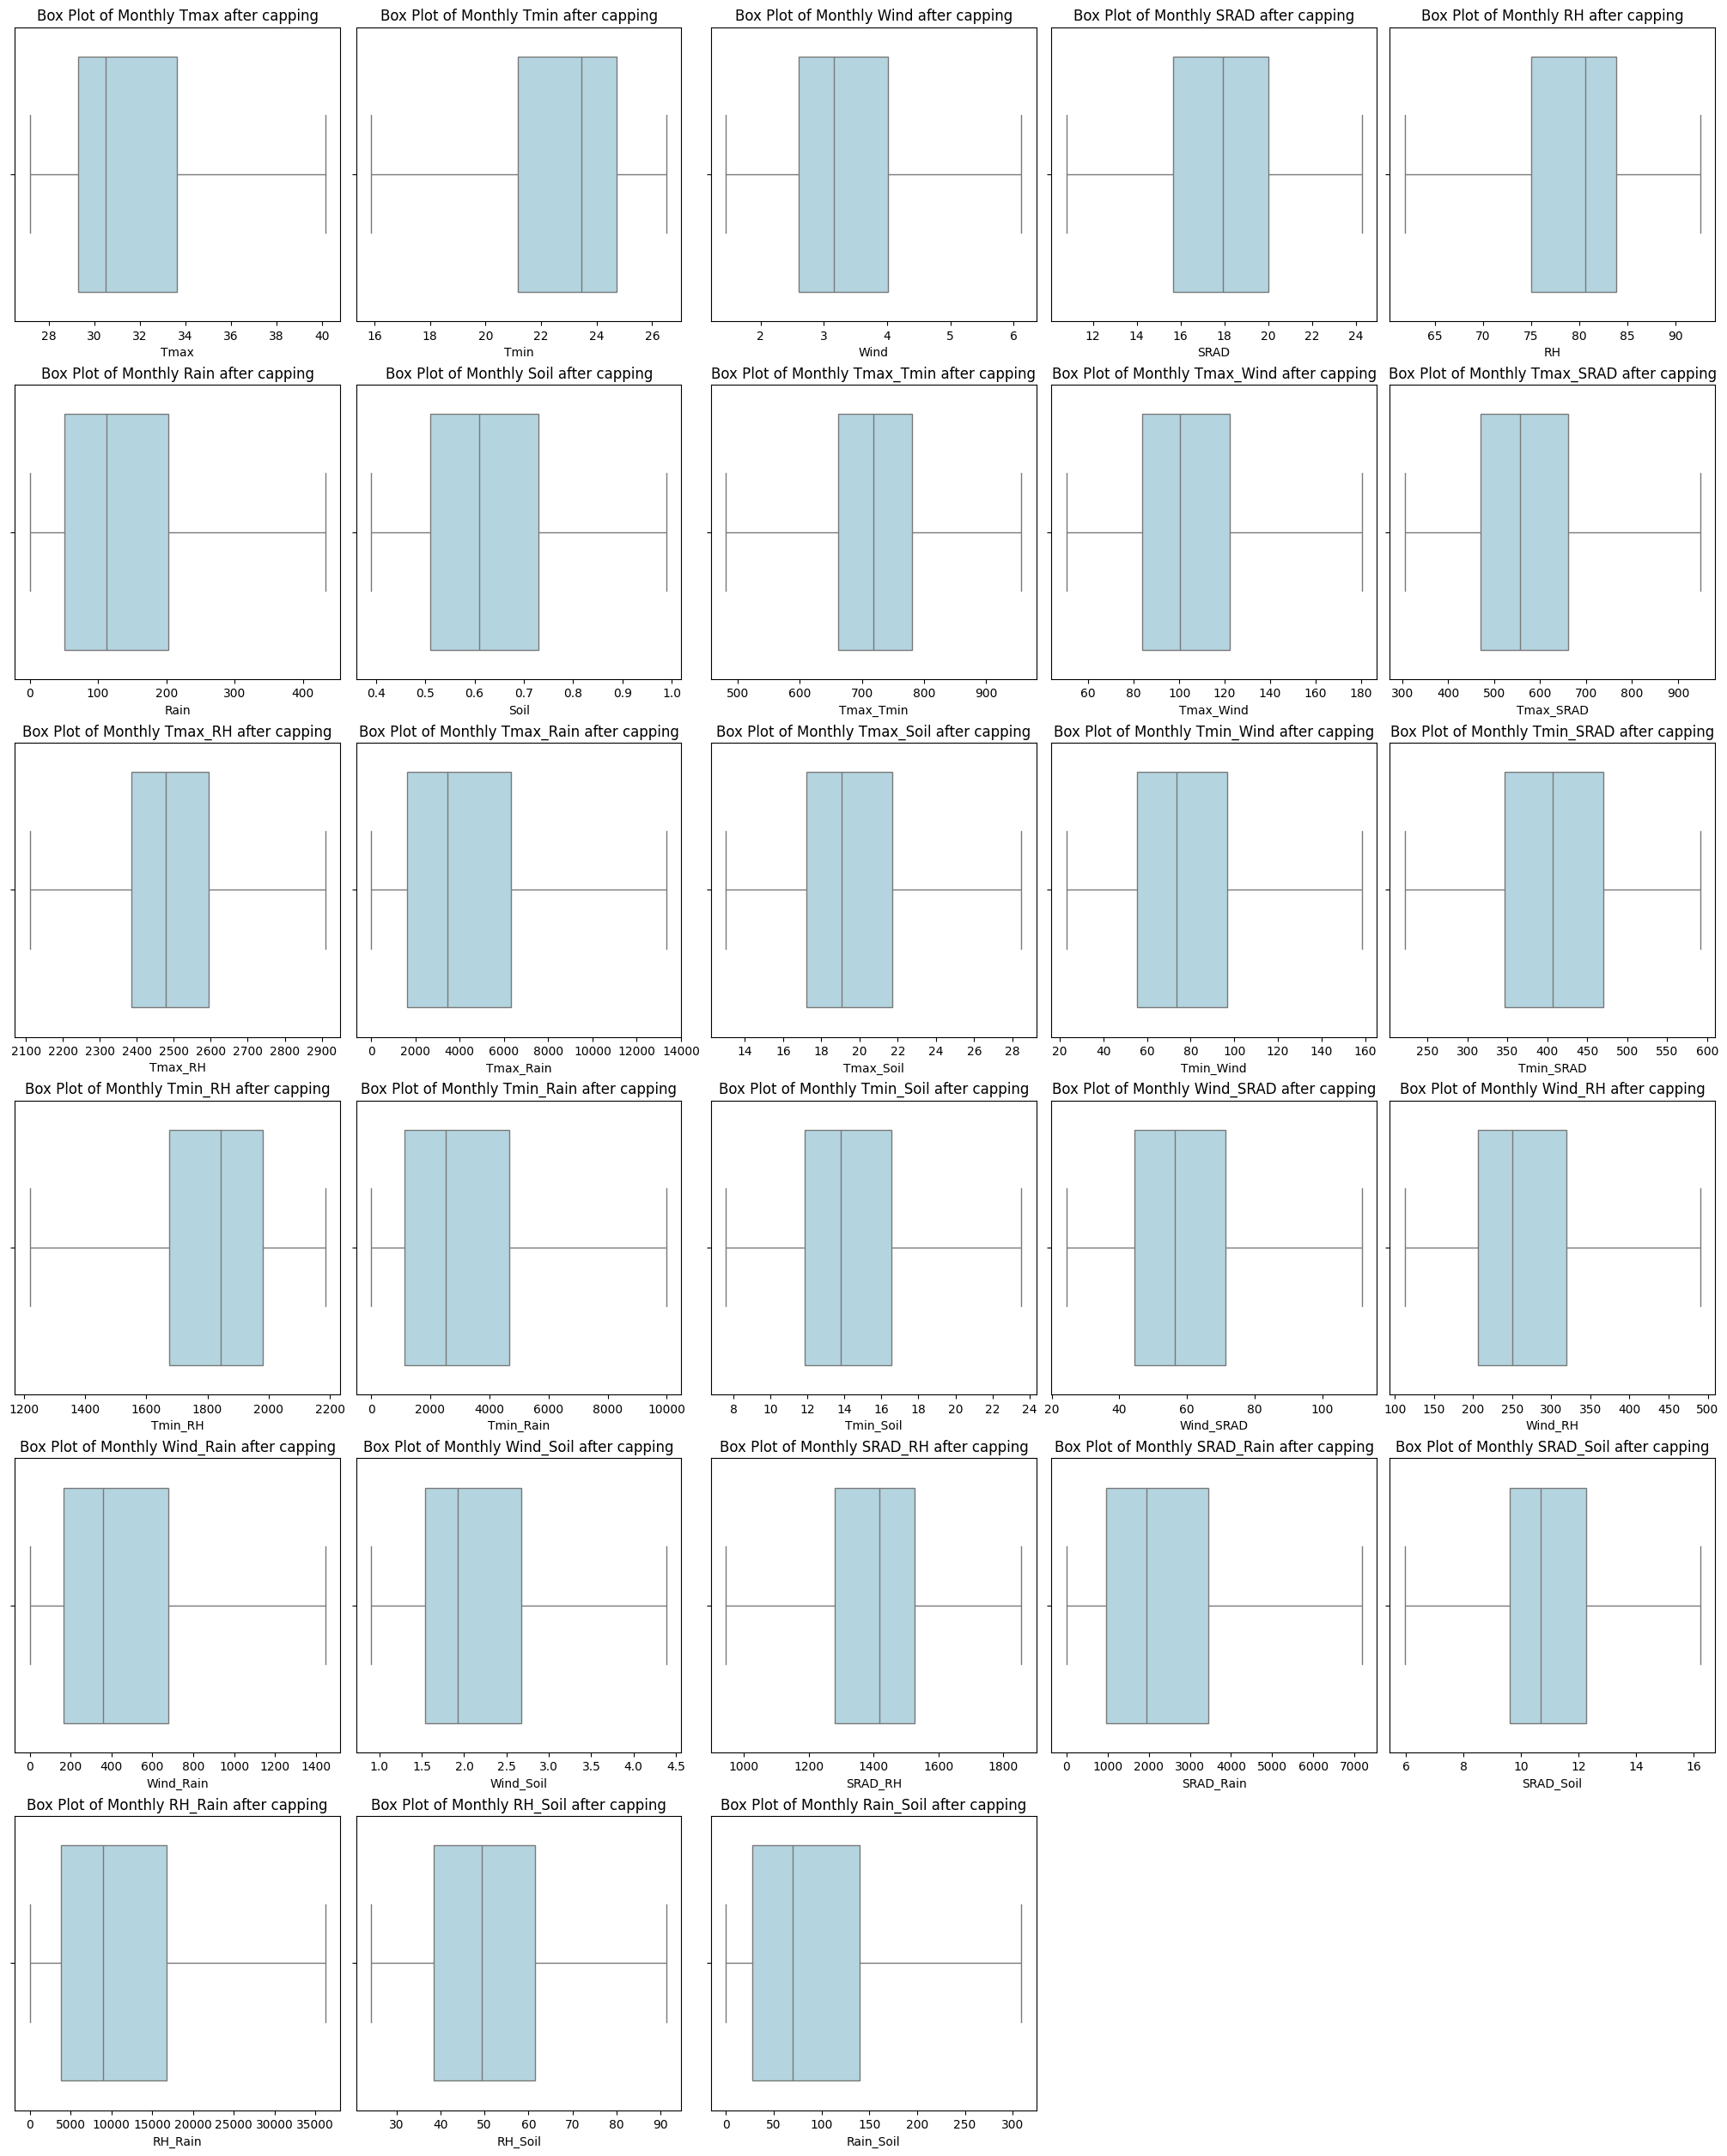

In [29]:
# Set fixed rows and columns
num_rows = 6
num_cols = 5

# Create subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(20, 25), constrained_layout=True)
axes = axes.flatten()

num_plots = min(len(numeric_cols_filtered), len(axes))

# Plot each numeric column
for i in range(num_plots):
    col = numeric_cols_filtered[i]
    sns.boxplot(ax=axes[i], x=maha_season_data[col], color='lightblue')
    axes[i].set_title(f'Box Plot of Monthly {col} after capping', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)

for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

# Show the plots
plt.show()

#### Aggregate Weather Indices

In [34]:
# Group by 'Cultivation_Season' and 'District' and aggregate using sum
aggregated_weather_indices = maha_season_data.groupby(['Cultivation_Season', 'District'])[numeric_cols_filtered].sum().reset_index()


# Display the updated simple weather indices
display(aggregated_weather_indices.head())



,Cultivation_Season,District,Tmax,Tmin,Wind,SRAD,RH,Rain,Soil,Tmax_Tmin,...,Wind_SRAD,Wind_RH,Wind_Rain,Wind_Soil,SRAD_RH,SRAD_Rain,SRAD_Soil,RH_Rain,RH_Soil,Rain_Soil
0,1984-1985,AMPARA,208.83,169.74,20.92,125.55,555.95,1038.56,4.82,5071.5900,...,370.372900,1669.4220,2969.512500,14.5547,9931.0757,18720.9104,85.5435,81932.8612,384.4747,709.5801
1,1984-1985,ANURADHAPURA,219.56,131.08,16.21,124.27,593.44,1114.30,5.11,4119.9780,...,285.175000,1368.3424,2761.012100,11.7580,10512.2910,19510.6391,90.0488,93913.7742,435.2154,799.1622
2,1984-1985,HAMBANTOTA,202.38,168.41,27.71,130.35,571.55,1087.42,4.67,4870.0757,...,515.186113,2266.1250,4265.686100,18.3812,10633.5498,20342.2591,86.4763,88744.2819,381.7000,739.9073
3,1984-1985,POLONNARUWA,219.45,147.32,18.22,125.55,581.71,1119.73,4.56,4621.9968,...,327.069700,1509.9331,3018.452600,11.8233,10391.9506,20151.1702,80.7844,92588.6377,380.6809,718.6621
4,1985-1986,AMPARA,208.71,170.62,21.98,120.52,554.90,1208.62,4.92,5097.2514,...,371.273400,1757.1377,3923.752737,15.7438,9496.8006,20150.0482,83.7818,97159.4180,393.3820,878.5033


## Merge Weather and Yield Data

In [35]:
# Merge the weather and yield data
full_df = pd.merge(aggregated_weather_indices, maha_yield, on=['Cultivation_Season', 'District'], how='inner')

display(full_df.head())


,Cultivation_Season,District,Tmax,Tmin,Wind,SRAD,RH,Rain,Soil,Tmax_Tmin,...,Wind_Rain,Wind_Soil,SRAD_RH,SRAD_Rain,SRAD_Soil,RH_Rain,RH_Soil,Rain_Soil,Year,Maha_Yield
0,1984-1985,AMPARA,208.83,169.74,20.92,125.55,555.95,1038.56,4.82,5071.5900,...,2969.512500,14.5547,9931.0757,18720.9104,85.5435,81932.8612,384.4747,709.5801,1985,3827
1,1984-1985,ANURADHAPURA,219.56,131.08,16.21,124.27,593.44,1114.30,5.11,4119.9780,...,2761.012100,11.7580,10512.2910,19510.6391,90.0488,93913.7742,435.2154,799.1622,1985,3972
2,1984-1985,HAMBANTOTA,202.38,168.41,27.71,130.35,571.55,1087.42,4.67,4870.0757,...,4265.686100,18.3812,10633.5498,20342.2591,86.4763,88744.2819,381.7000,739.9073,1985,4328
3,1984-1985,POLONNARUWA,219.45,147.32,18.22,125.55,581.71,1119.73,4.56,4621.9968,...,3018.452600,11.8233,10391.9506,20151.1702,80.7844,92588.6377,380.6809,718.6621,1985,4874
4,1985-1986,AMPARA,208.71,170.62,21.98,120.52,554.90,1208.62,4.92,5097.2514,...,3923.752737,15.7438,9496.8006,20150.0482,83.7818,97159.4180,393.3820,878.5033,1986,3287


### Explore Dataset

In [36]:
# Display dataset info
print("Dataset Info:")
print(full_df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cultivation_Season  124 non-null    object 
 1   District            124 non-null    object 
 2   Tmax                124 non-null    float64
 3   Tmin                124 non-null    float64
 4   Wind                124 non-null    float64
 5   SRAD                124 non-null    float64
 6   RH                  124 non-null    float64
 7   Rain                124 non-null    float64
 8   Soil                124 non-null    float64
 9   Tmax_Tmin           124 non-null    float64
 10  Tmax_Wind           124 non-null    float64
 11  Tmax_SRAD           124 non-null    float64
 12  Tmax_RH             124 non-null    float64
 13  Tmax_Rain           124 non-null    float64
 14  Tmax_Soil           124 non-null    float64
 15  Tmin_Wind           124 non-null    float64

In [37]:
# Summary statistics
print("\nSummary Statistics:")
print(full_df.describe())


Summary Statistics:
             Tmax        Tmin        Wind        SRAD          RH  \
count  124.000000  124.000000  124.000000  124.000000  124.000000   
mean   221.226028  159.703548   23.671815  125.017823  555.137460   
std     13.001614   13.859738    4.987655    4.915705   25.334894   
min    201.000000  131.080000   16.210000  112.220000  465.425000   
25%    211.130000  147.845000   19.637500  122.015000  541.182500   
50%    218.610000  164.420000   22.470000  124.960000  557.555000   
75%    230.582500  172.597500   27.170000  128.430000  573.985000   
max    258.767500  177.590000   36.665000  139.130000  608.800000   

              Rain        Soil    Tmax_Tmin    Tmax_Wind    Tmax_SRAD  ...  \
count   124.000000  124.000000   124.000000   124.000000   124.000000  ...   
mean    984.980817    4.420565  5037.639850   740.349686  3980.214654  ...   
std     449.742913    0.697993   277.399004   126.208740   270.661455  ...   
min     139.710000    2.890000  4119.978000  

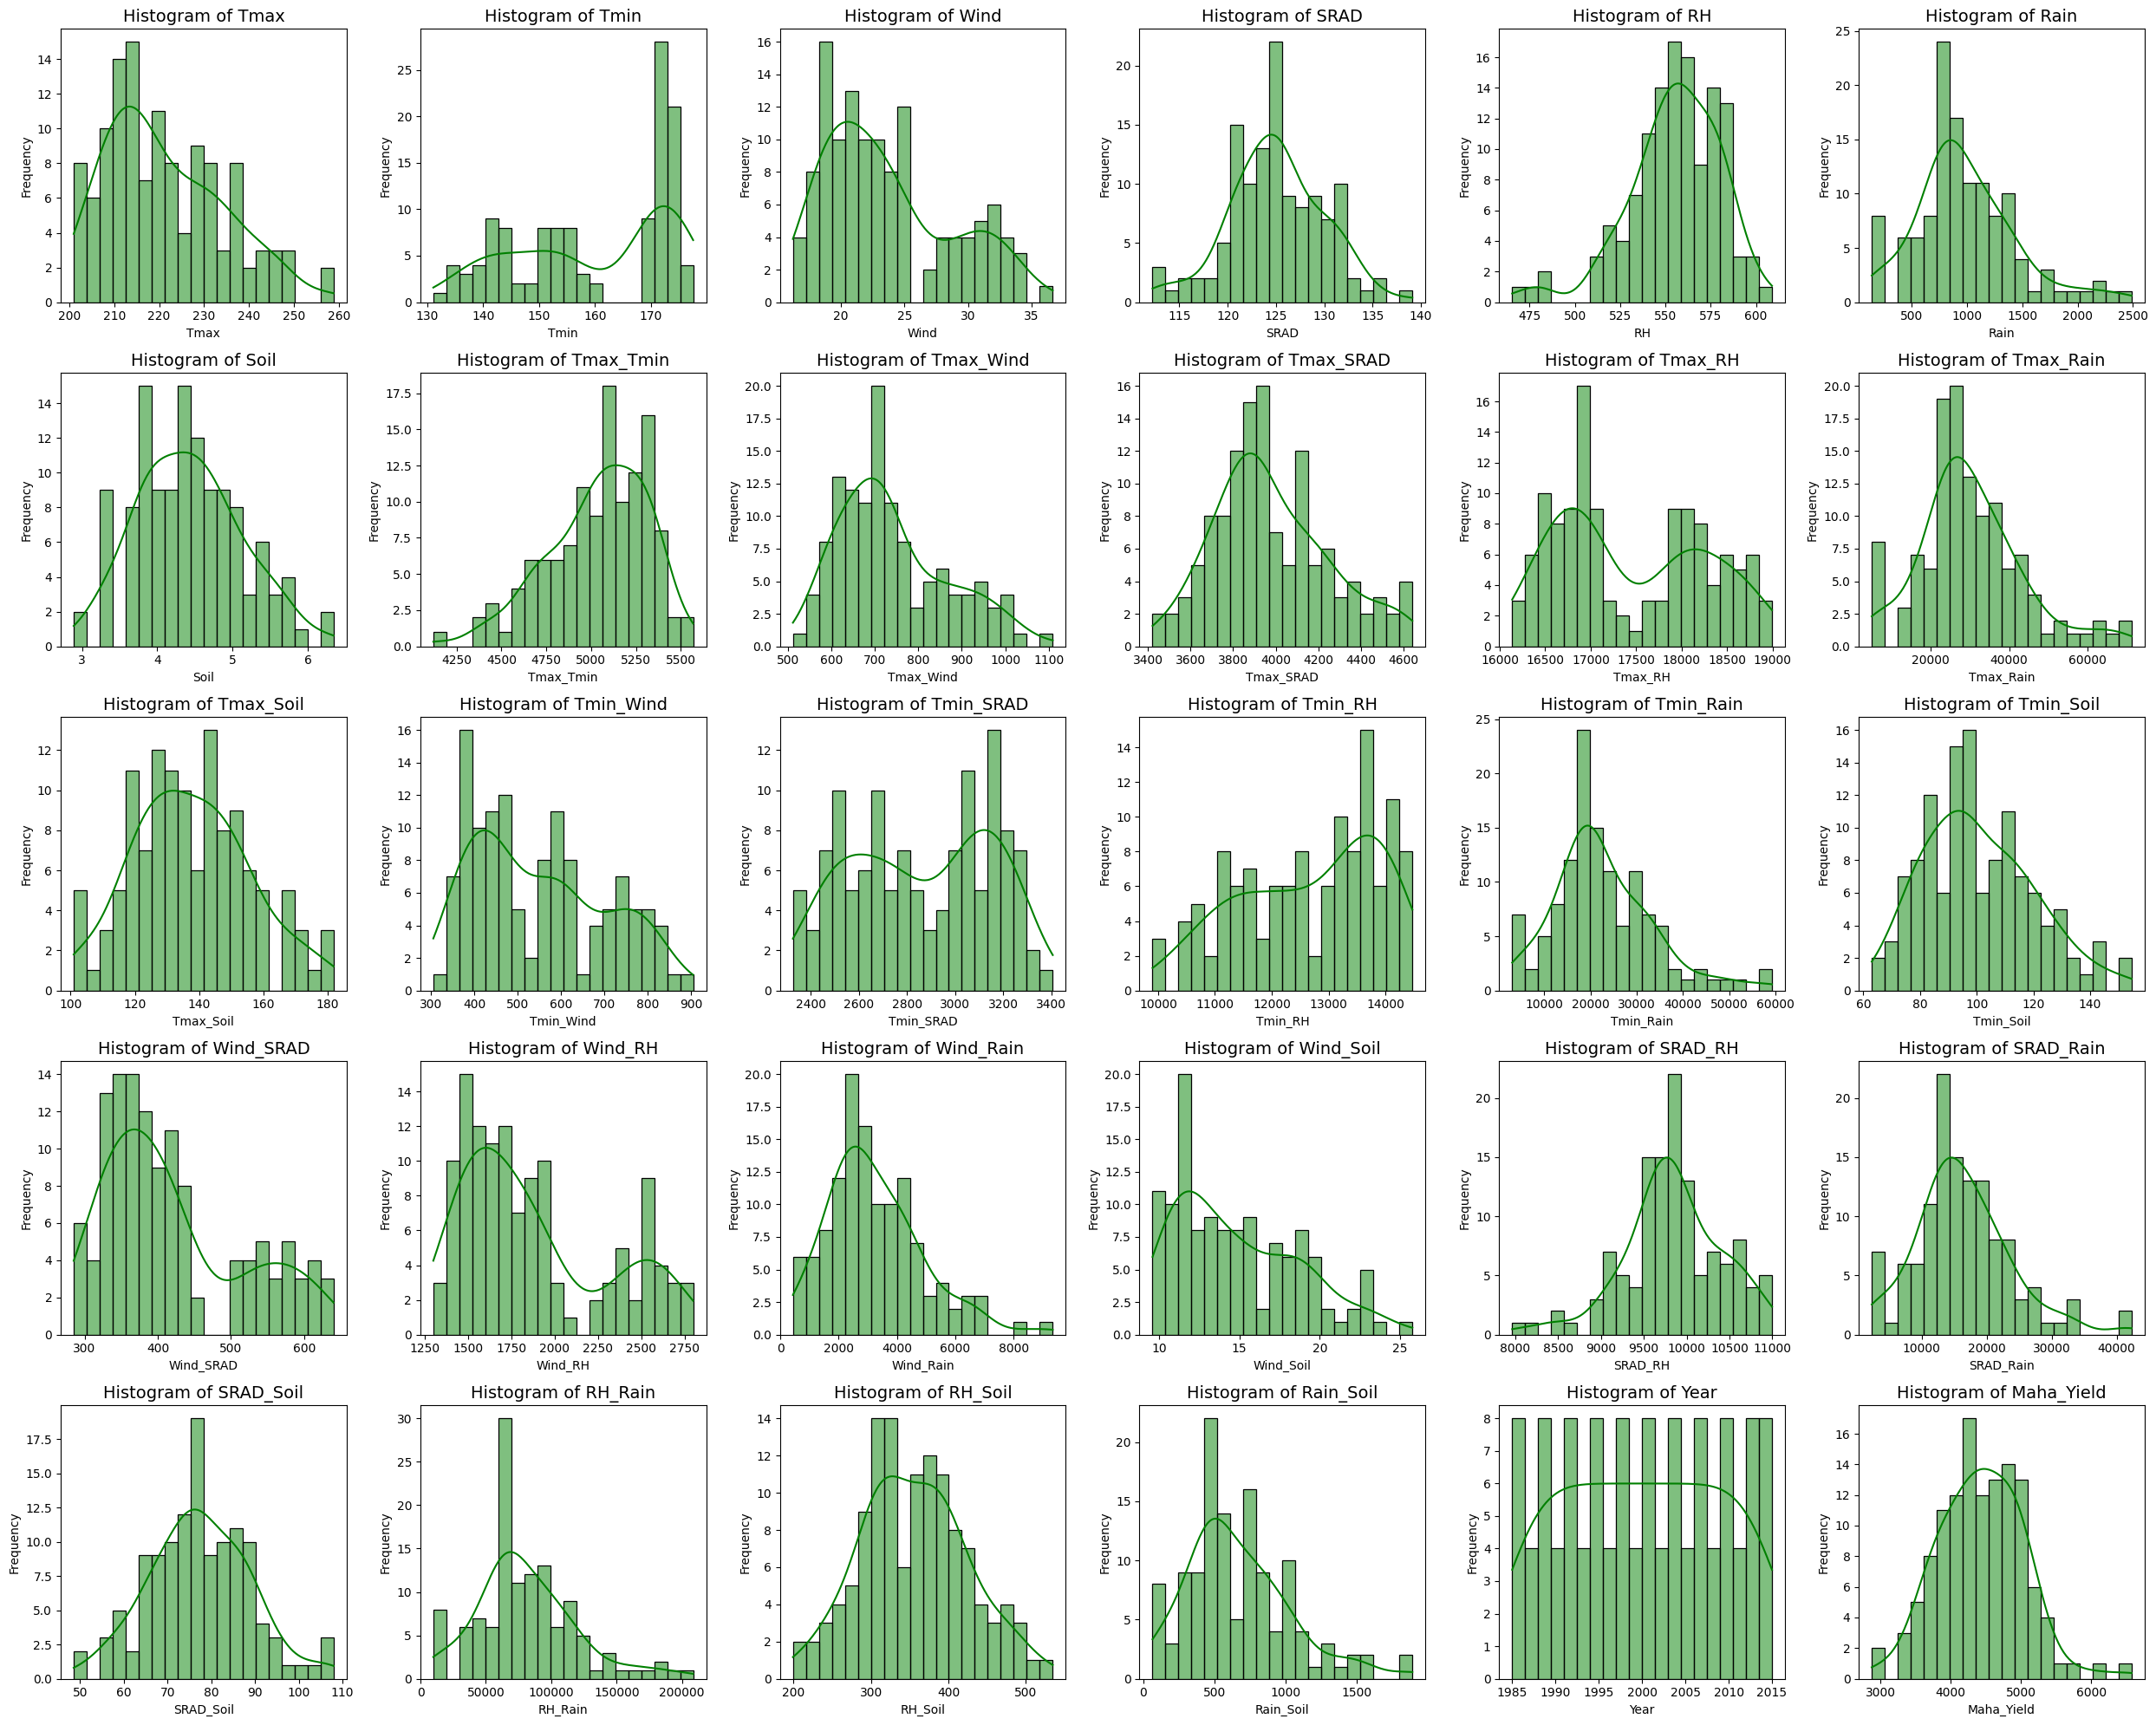

In [46]:
# Select only numerical columns
num_cols = full_df.select_dtypes(include=['int64', 'float64']).columns

# Set up subplots
fig, axes = plt.subplots(5, 6, figsize=(25, 20))
axes = axes.flatten()

# Generate separate histograms for each numerical column
for i, col in enumerate(num_cols):
    sns.histplot(full_df[col], bins=20, kde=True, ax=axes[i], edgecolor='black', color='green')
    axes[i].set_title(f"Histogram of {col}", fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


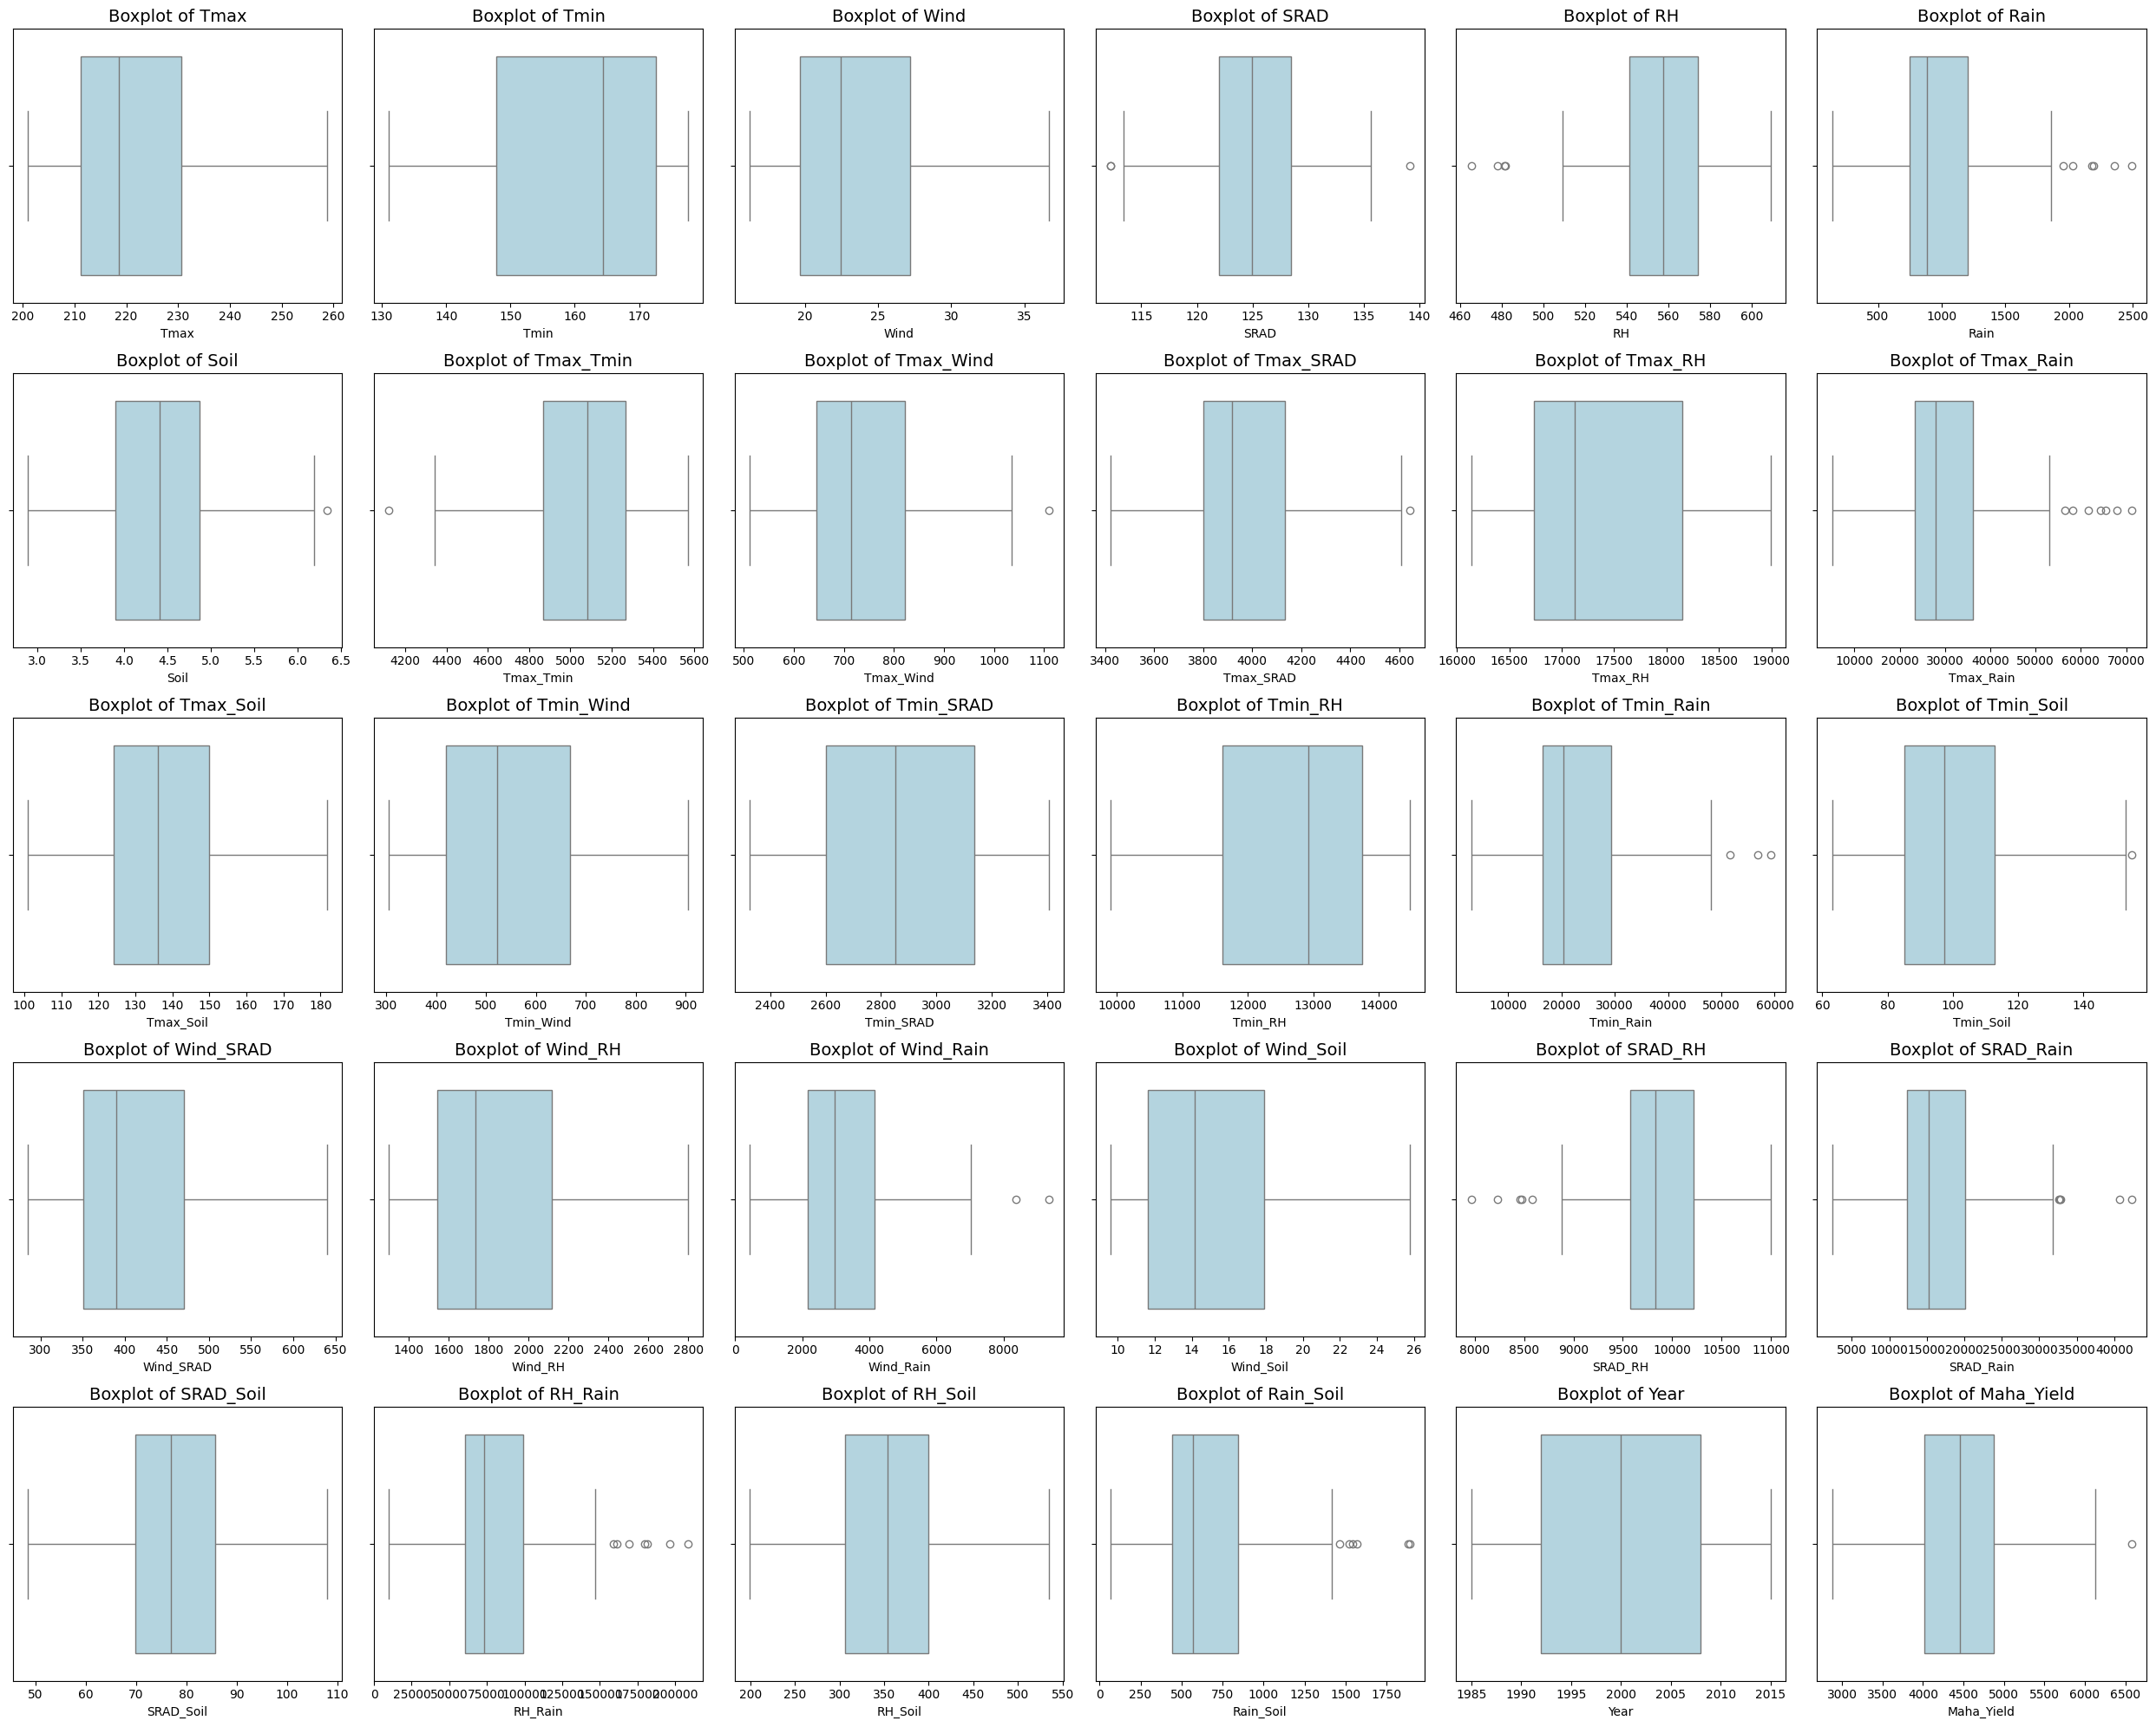

In [47]:
# Select only numerical columns
num_cols = full_df.select_dtypes(include=['int64', 'float64']).columns

# Set up subplots
fig, axes = plt.subplots(5, 6, figsize=(25, 20))

axes = axes.flatten()

# Generate boxplots for each numerical column
for i, col in enumerate(num_cols):
    sns.boxplot(x=full_df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f"Boxplot of {col}", fontsize=14)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Handle Outliers

In [48]:
# Handle outliers
for col in num_cols:
    full_df[col] = cap_outliers(full_df, col)


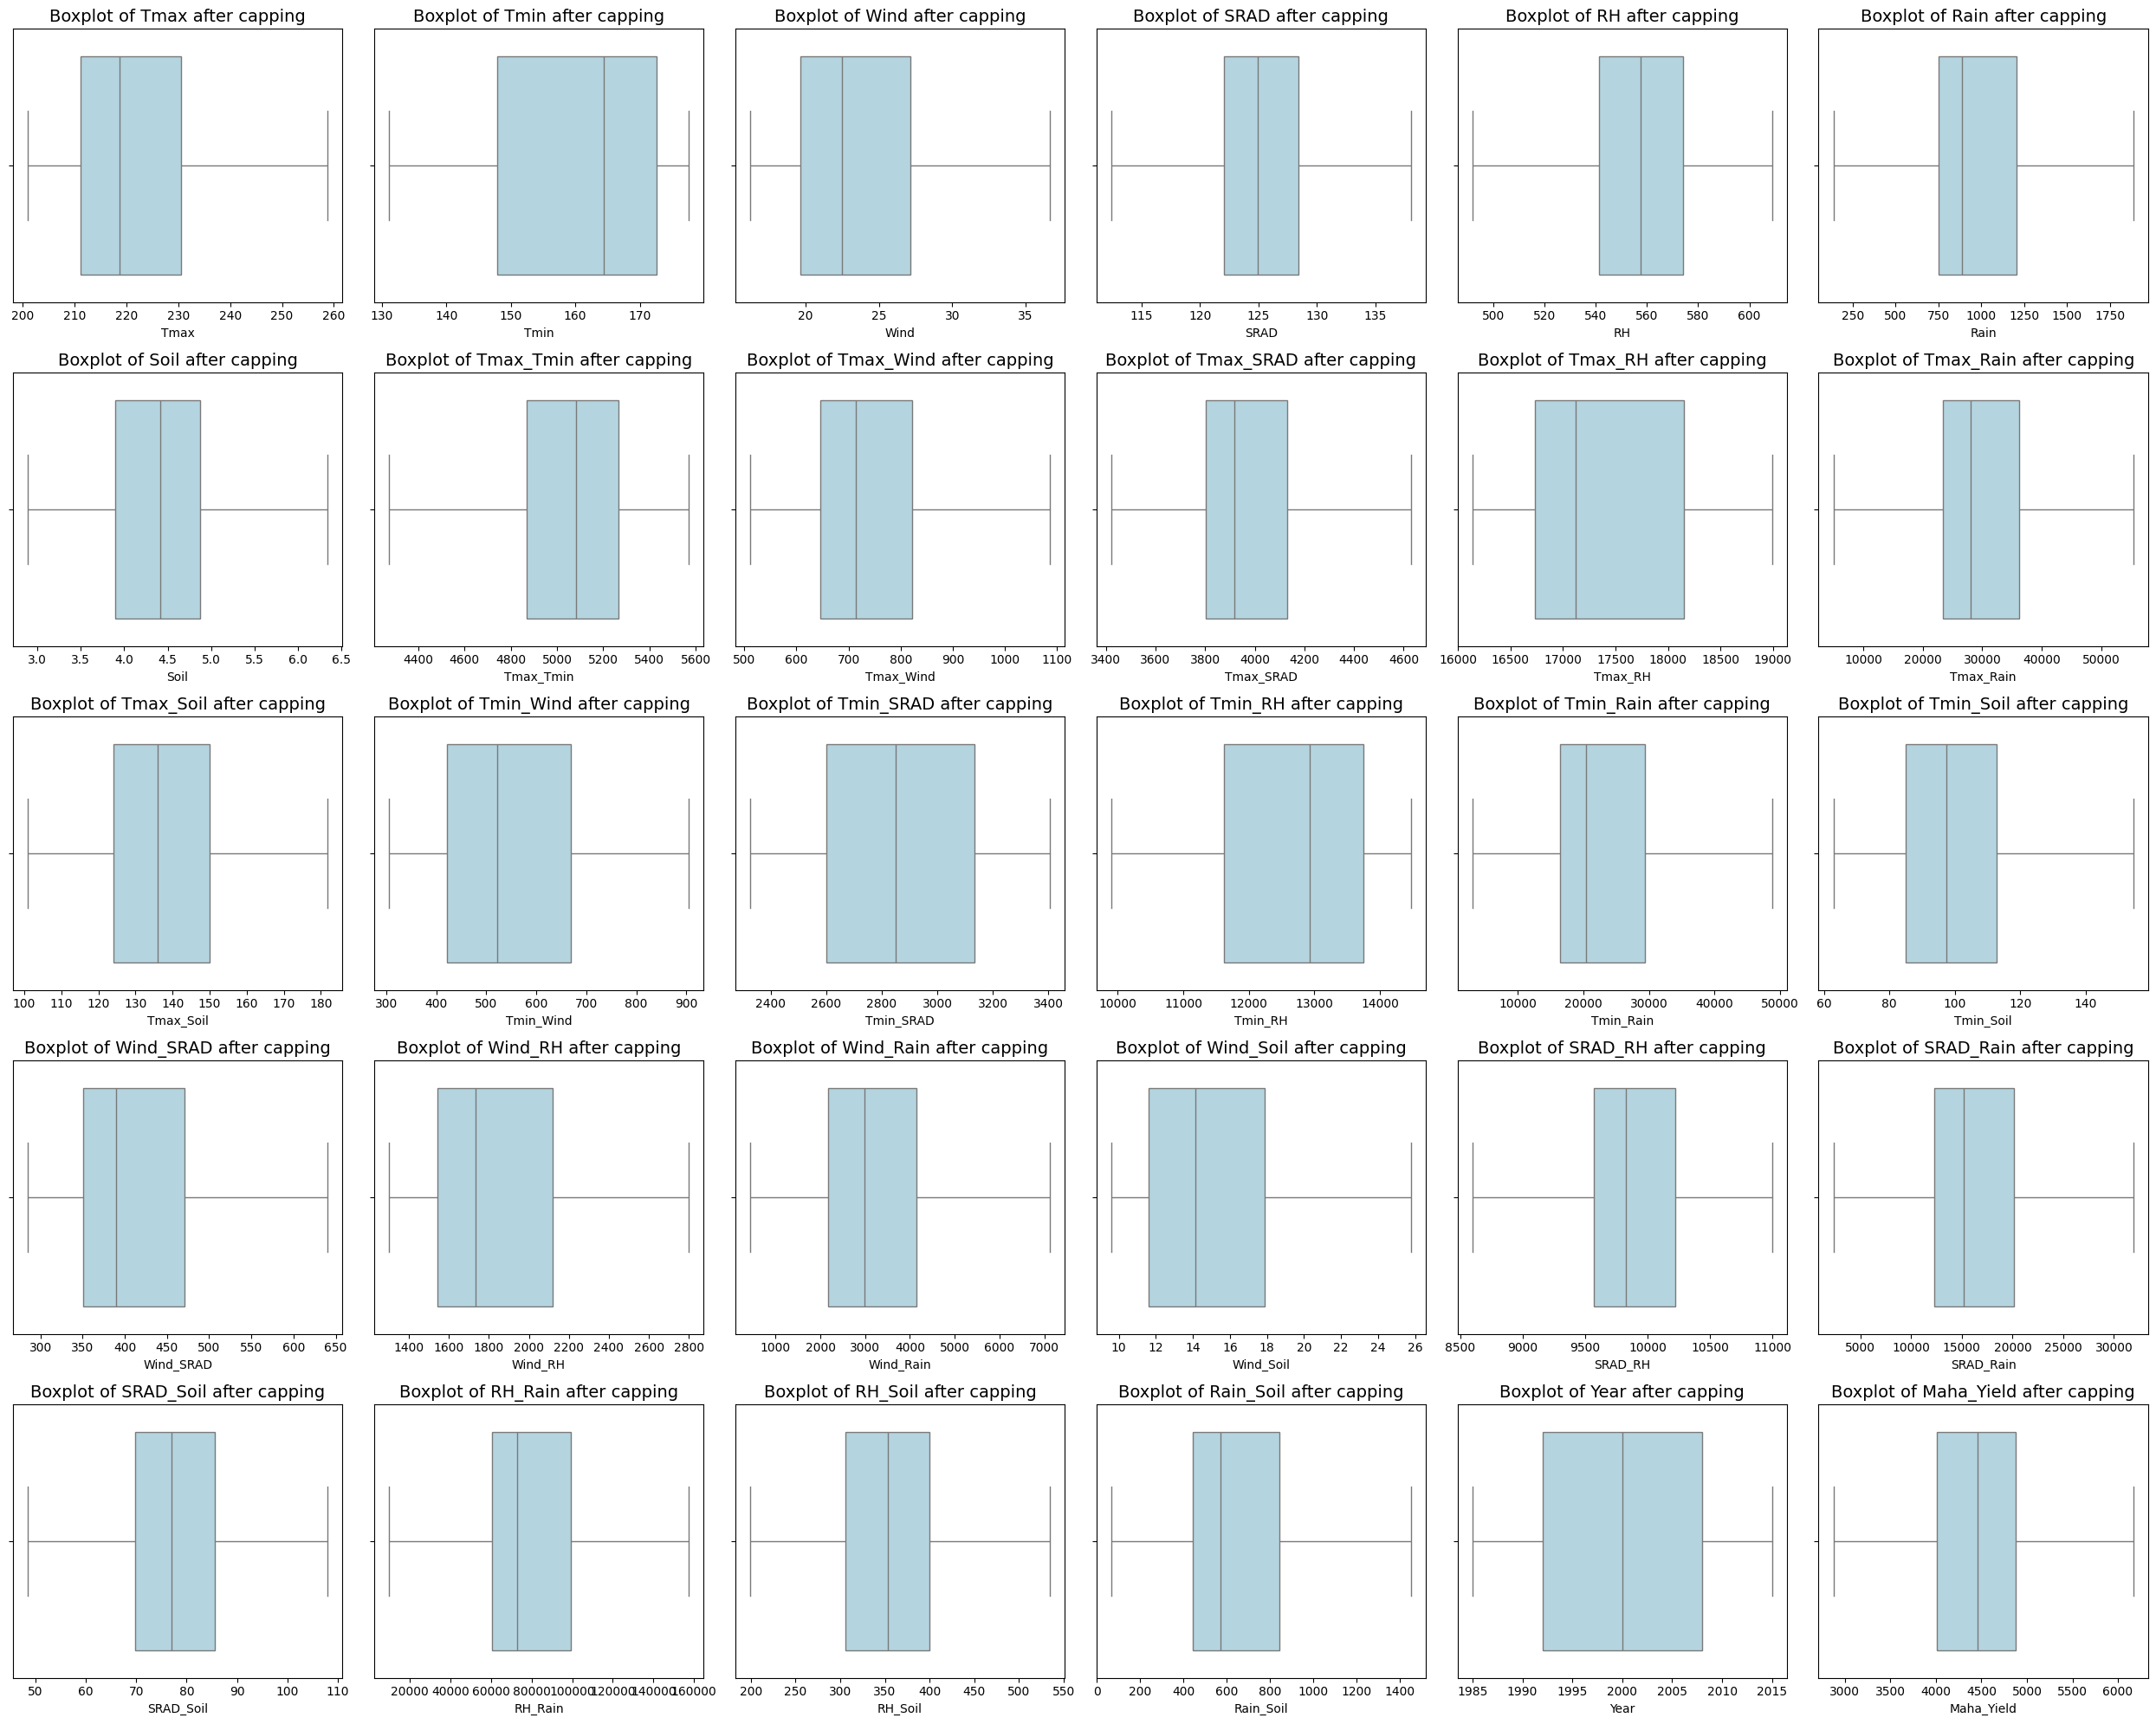

In [50]:
# Set up subplots
fig, axes = plt.subplots(5, 6, figsize=(25, 20))
axes = axes.flatten()

# Generate boxplots for each numerical column
for i, col in enumerate(num_cols):
    sns.boxplot(x=full_df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f"Boxplot of {col} after capping", fontsize=14)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [51]:
# Save the full dataset to a CSV file
full_df.to_csv('FULL_yield_prediction_data.csv', index=False)
full_df.to_csv('/content/drive/MyDrive/Datasets/FULL_yield_prediction_data.csv', index=False)

### Check Correlation Between Variables

In [53]:
full_df = pd.read_csv('/content/drive/MyDrive/Datasets/FULL_yield_prediction_data.csv')


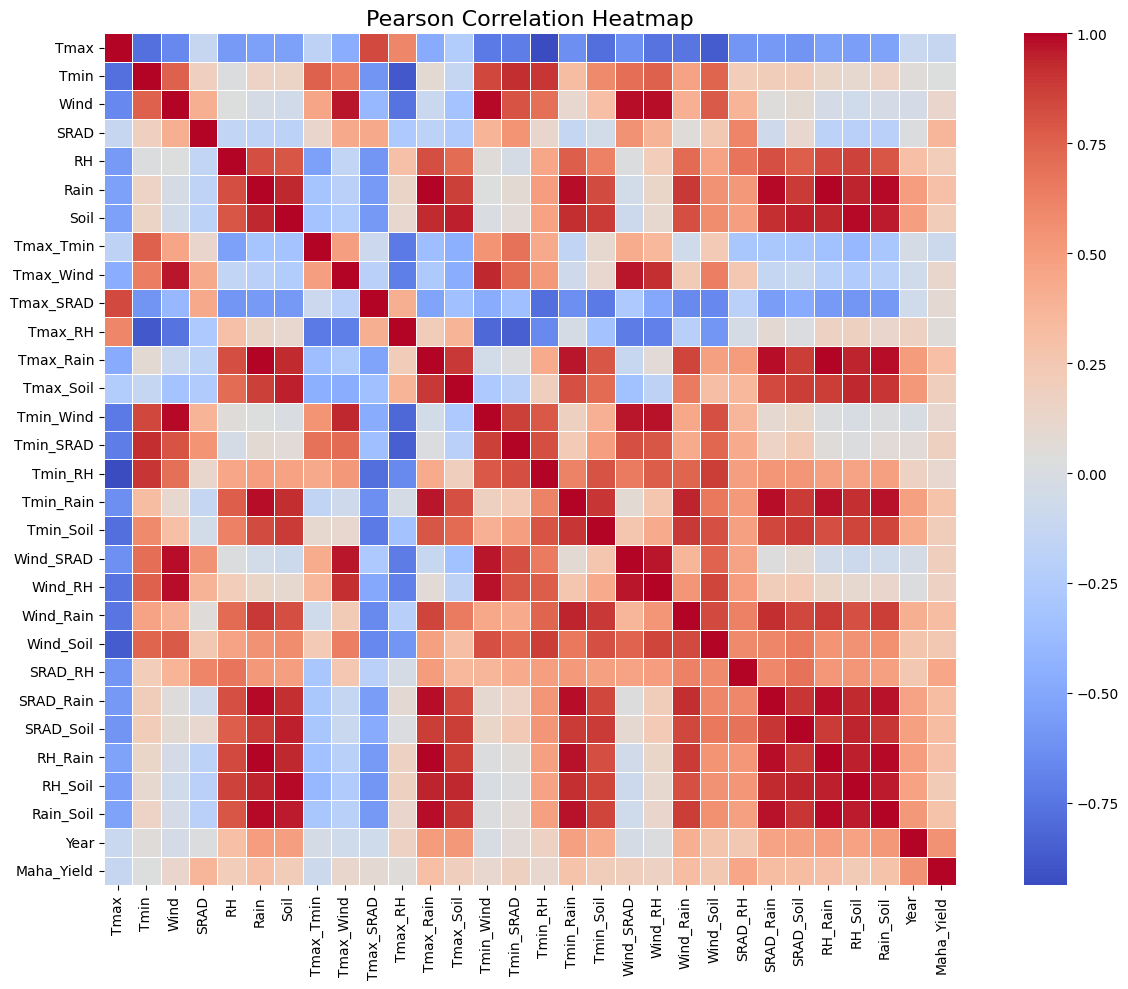

In [54]:
# Select numerical columns
num_cols = full_df.select_dtypes(include=['int64', 'float64']).columns

# Compute Pearson correlation matrix
corr_matrix = full_df[num_cols].corr()

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Pearson Correlation Heatmap", fontsize=16)
plt.tight_layout()


plt.show()

In [55]:
# Compute Pearson correlation matrix
num_cols = full_df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = full_df[num_cols].corr().abs()

# Select the upper triangle of correlation matrix
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns with correlation above threshold
threshold = 0.8
drop_cols = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]

# Drop the selected columns
full_df.drop(columns=drop_cols, inplace=True)

print(f"Dropped Columns due to high correlation: {drop_cols}")
print("Remaining Columns:", full_df.columns)


Dropped Columns due to high correlation: ['Rain', 'Soil', 'Tmax_Wind', 'Tmax_SRAD', 'Tmax_RH', 'Tmax_Rain', 'Tmax_Soil', 'Tmin_Wind', 'Tmin_SRAD', 'Tmin_RH', 'Tmin_Rain', 'Tmin_Soil', 'Wind_SRAD', 'Wind_RH', 'Wind_Rain', 'Wind_Soil', 'SRAD_Rain', 'SRAD_Soil', 'RH_Rain', 'RH_Soil', 'Rain_Soil']
Remaining Columns: Index(['Cultivation_Season', 'District', 'Tmax', 'Tmin', 'Wind', 'SRAD', 'RH',
       'Tmax_Tmin', 'SRAD_RH', 'Year', 'Maha_Yield'],
      dtype='object')


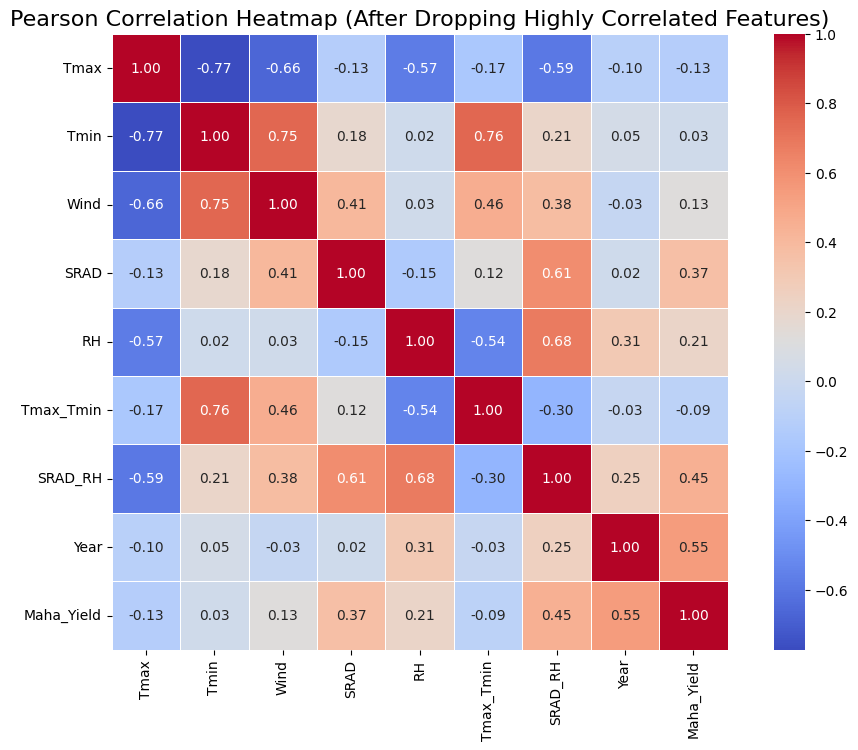

In [56]:
# Compute Pearson correlation matrix
remaining_num_cols = full_df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix_remaining = full_df[remaining_num_cols].corr()

# Plot the heatma
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix_remaining,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Pearson Correlation Heatmap (After Dropping Highly Correlated Features)", fontsize=16)

plt.show()

### Encode Data

In [58]:
# One-hot encode the District column
encoded_df = pd.get_dummies(full_df, columns=['District'], prefix='District', dtype=int)

# Drop Cultivation_Season
encoded_df.drop(columns=['Cultivation_Season'], inplace=True)

# Display the resulting DataFrame
display(encoded_df)


,Tmax,Tmin,Wind,SRAD,RH,Tmax_Tmin,SRAD_RH,Year,Maha_Yield,District_AMPARA,District_ANURADHAPURA,District_HAMBANTOTA,District_POLONNARUWA
0,208.83,169.74,20.92,125.55,555.95,5071.590000,9931.0757,1985,3827.0,1,0,0,0
1,219.56,131.08,16.21,124.27,593.44,4273.974969,10512.2910,1985,3972.0,0,1,0,0
2,202.38,168.41,27.71,130.35,571.55,4870.075700,10633.5498,1985,4328.0,0,0,1,0
3,219.45,147.32,18.22,125.55,581.71,4621.996800,10391.9506,1985,4874.0,0,0,0,1
4,208.71,170.62,21.98,120.52,554.90,5097.251400,9496.8006,1986,3287.0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,231.13,155.16,21.96,125.94,542.28,5133.784700,9625.6568,2014,4819.0,0,0,0,1
120,212.69,174.25,22.73,121.07,560.97,5303.577300,9606.9936,2015,4078.0,1,0,0,0
121,223.96,143.33,17.01,120.64,596.44,4613.122100,10168.6940,2015,4802.0,0,1,0,0
122,203.68,173.82,29.08,131.28,582.83,5058.539900,10895.4780,2015,6134.0,0,0,1,0


In [59]:
# Save the processed DataFrame to a CSV file
encoded_df.to_csv("ENCODED_yield_pred_data.csv", index=False)
encoded_df.to_csv("/content/drive/MyDrive/Datasets/ENCODED_yield_pred_data.csv", index=False)

### Augment Data

In [61]:
# Define function for Data Augementation
def augment_data_gaussian(df, numerical_cols, num_copies=4, noise_factor=0.02, seed=4):
    np.random.seed(seed)
    augmented_data = []

    for _ in range(num_copies):
        noisy_df = df.copy()

        for col in numerical_cols:
            std_dev = df[col].std()
            noise = np.random.normal(0, noise_factor * std_dev, df.shape[0])
            noisy_df[col] += noise

        augmented_data.append(noisy_df)

    augmented_df = pd.concat([df] + augmented_data, ignore_index=True)

    return augmented_df



In [64]:
# Load dataset
df = pd.read_csv("ENCODED_yield_pred_data.csv")

# Identify numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.difference(["Year", "Maha_Yield"] + [col for col in df.columns if "District" in col])

# Apply augmentation
df_augmented = augment_data_gaussian(df, numerical_cols)

# Save the augmented dataset
df_augmented.to_csv("AUG_yield_pred_data.csv", index=False)
df_augmented.to_csv("/content/drive/MyDrive/Datasets/AUG_yield_pred_data.csv", index=False)

display(df_augmented.head())


,Tmax,Tmin,Wind,SRAD,RH,Tmax_Tmin,SRAD_RH,Year,Maha_Yield,District_AMPARA,District_ANURADHAPURA,District_HAMBANTOTA,District_POLONNARUWA
0,208.83,169.74,20.92,125.55,555.95,5071.590000,9931.0757,1985,3827.0,1,0,0,0
1,219.56,131.08,16.21,124.27,593.44,4273.974969,10512.2910,1985,3972.0,0,1,0,0
2,202.38,168.41,27.71,130.35,571.55,4870.075700,10633.5498,1985,4328.0,0,0,1,0
3,219.45,147.32,18.22,125.55,581.71,4621.996800,10391.9506,1985,4874.0,0,0,0,1
4,208.71,170.62,21.98,120.52,554.90,5097.251400,9496.8006,1986,3287.0,1,0,0,0


In [65]:
df_augmented.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Tmax                   620 non-null    float64
 1   Tmin                   620 non-null    float64
 2   Wind                   620 non-null    float64
 3   SRAD                   620 non-null    float64
 4   RH                     620 non-null    float64
 5   Tmax_Tmin              620 non-null    float64
 6   SRAD_RH                620 non-null    float64
 7   Year                   620 non-null    int64  
 8   Maha_Yield             620 non-null    float64
 9   District_AMPARA        620 non-null    int64  
 10  District_ANURADHAPURA  620 non-null    int64  
 11  District_HAMBANTOTA    620 non-null    int64  
 12  District_POLONNARUWA   620 non-null    int64  
dtypes: float64(8), int64(5)
memory usage: 63.1 KB


## Split Data into Train-Test Sets

In [66]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

In [68]:
# Load dataset
df = pd.read_csv("AUG_yield_pred_data.csv")

# Drop Year
df = df.drop(columns=["Year"])

# Perform 80-20 random train-test split
X = df.drop(columns=["Maha_Yield"])  # Features
y = df["Maha_Yield"]  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Scale Data

In [69]:
# Identify numerical features
numerical_cols = X_train.columns.difference([col for col in X_train.columns if "District" in col])

# Scale only numerical features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])  # Use same scaler


In [70]:
print(f"Original X_train shape: {X_train.shape}")
print(f"Original X_test shape: {X_test.shape}")
print(f"Scaled X_train shape: {X_train_scaled.shape}")
print(f"Scaled X_test shape: {X_test_scaled.shape}")


Original X_train shape: (496, 11)
Original X_test shape: (124, 11)
Scaled X_train shape: (496, 11)
Scaled X_test shape: (124, 11)


## Model Implementation - RF Regressor

### Baseline Model Implementation

In [71]:
# Initialize Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model using the scaled training set
rf_model.fit(X_train_scaled, y_train)


RandomForestRegressor(random_state=42)

In [72]:
# Make predictions on both training and testing sets
y_train_pred = rf_model.predict(X_train_scaled)  # Train predictions
y_test_pred = rf_model.predict(X_test_scaled)  # Test predictions

# Evaluate Training Performance
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)

# Evaluate Testing Performance
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# Print results
print(f"Training Performance:")
print(f"Train R² Score: {train_r2:.4f}")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Train MAE: {train_mae:.2f}")

print(f"\nTesting Performance:")
print(f"Test R² Score: {test_r2:.4f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test MAE: {test_mae:.2f}")



Training Performance:
Train R² Score: 0.9924
Train RMSE: 51.85
Train MAE: 28.70

Testing Performance:
Test R² Score: 0.9618
Test RMSE: 118.66
Test MAE: 79.18


### Hyperparameter Tuning Using Grid Search

In [77]:
# Define the parameter grid
param_grid = {
    'n_estimators': [150, 200],
    'max_depth': [14, 16, 18],
    'max_features': ['sqrt', 0.8],
    'min_samples_split': [16, 18],
    'min_samples_leaf': [8, 10],
    'bootstrap': [False]
}

In [79]:
# Initialize the Random Forest model
rf = RandomForestRegressor(random_state=42)

# Perform Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

# Fit Grid Search on the training set
grid_search.fit(X_train_scaled, y_train)



Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [False], 'max_depth': [14, 16, 18],
                         'max_features': ['sqrt', 0.8],
                         'min_samples_leaf': [8, 10],
                         'min_samples_split': [16, 18],
                         'n_estimators': [150, 200]},
             scoring='r2', verbose=2)

In [80]:
# Get the best parameters from Grid Search
best_params = grid_search.best_params_

# Train the best model with optimal hyperparameters
best_rf = RandomForestRegressor(**best_params, random_state=42)
best_rf.fit(X_train_scaled, y_train)

RandomForestRegressor(bootstrap=False, max_depth=16, max_features=0.8,
                      min_samples_leaf=8, min_samples_split=16,
                      n_estimators=200, random_state=42)

In [81]:
# Make predictions on both training and testing sets
y_train_pred = best_rf.predict(X_train_scaled)
y_test_pred = best_rf.predict(X_test_scaled)

# Evaluate Training Performance
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)

# Evaluate Testing Performance
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# Print Model Performance Results
print("Training Performance:")
print(f"Train R² Score: {train_r2:.4f}")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Train MAE: {train_mae:.2f}")

print("\nTesting Performance:")
print(f"Test R² Score: {test_r2:.4f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test MAE: {test_mae:.2f}")

Training Performance:
Train R² Score: 0.9445
Train RMSE: 139.93
Train MAE: 99.28

Testing Performance:
Test R² Score: 0.8901
Test RMSE: 201.36
Test MAE: 157.74


In [82]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

# Define 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)


# Apply Cross-Validation
cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=kf, scoring='r2')

# Print results
print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean CV R² Score: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation of R²: {np.std(cv_scores):.4f}")


Cross-Validation R² Scores: [0.72194229 0.82093628 0.82851255 0.85595471 0.7743608 ]
Mean CV R² Score: 0.8003
Standard Deviation of R²: 0.0472
